### Pacotes importados

In [1]:
using LinearAlgebra
using Printf

## Chapter 13: Quasi-Newton methods

### Algorithm 13.1: Quasi-Newton BFGS method

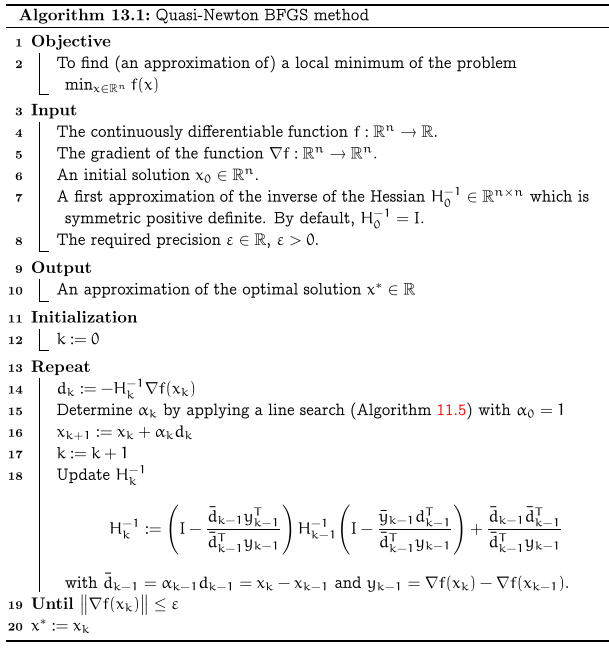

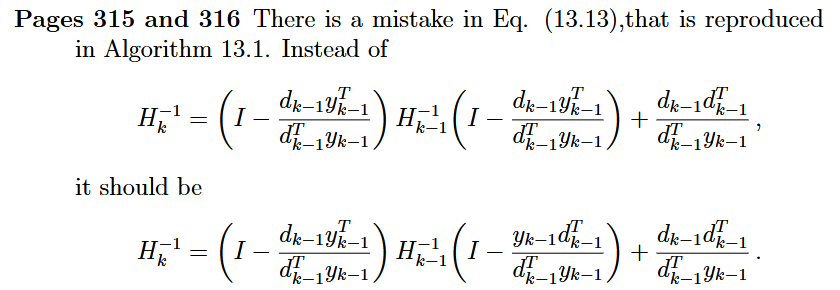

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$

In [4]:
using LinearAlgebra
using Printf

# --- SUB-ROTINA: BUSCA LINEAR DE WOLFE (Algoritmo 11.5) ---
function busca_linear_wolfe(f, grad, x, d; alpha0=1.0, beta1=1e-4, beta2=0.9)
    alpha_low = 0.0
    alpha_high = Inf
    alpha = alpha0
    f0 = f(x)
    g0 = dot(grad(x), d)
    
    for i in 1:50
        fi = f(x + alpha * d)
        gi = dot(grad(x + alpha * d), d)
        if fi > f0 + beta1 * alpha * g0
            alpha_high = alpha
            alpha = (alpha_low + alpha_high) / 2
        elseif gi < beta2 * g0
            alpha_low = alpha
            alpha = isinf(alpha_high) ? alpha * 2.0 : (alpha_low + alpha_high) / 2
        else
            return alpha
        end
    end
    return alpha
end

# --- IMPLEMENTAÇÃO BFGS (Algoritmo 13.1) ---
function algoritmo_bfgs(f, grad, x0, eps)
    xk = Float64.(x0)
    n = length(xk)
    H_inv = Matrix(1.0I, n, n)
    k = 0
    
    println("Iteração | f(xk)          | ||grad f(xk)||")
    println("-"^45)
    
    while norm(grad(xk)) > eps && k < 500
        gk = grad(xk)
        @printf("%-8d | %-14.10f | %-14.10e\n", k, f(xk), norm(gk))
        
        # 1. Direção de descida
        dk = -H_inv * gk
        
        # 2. Busca Linear
        ak = busca_linear_wolfe(f, grad, xk, dk)
        
        # 3. Atualização
        x_old, g_old = xk, gk
        xk = xk + ak * dk
        
        # 4. Atualização BFGS (Fórmula Corrigida)
        sk = xk - x_old
        yk = grad(xk) - g_old
        skyk = dot(yk, sk)
        
        if skyk > 1e-10
            rho = 1.0 / skyk
            I_mat = Matrix(1.0I, n, n)
            H_inv = (I_mat - rho * sk * yk') * H_inv * (I_mat - rho * yk * sk') + (rho * sk * sk')
        end
        k += 1
    end
    @printf("%-8d | %-14.10f | %-14.10e\n", k, f(xk), norm(grad(xk)))
    return xk
end

# --- EXECUÇÃO EXEMPLO 5.8 ---
f58(x) = x[2] + x[1] * cos(x[2])
grad_f58(x) = [cos(x[2]), 1 - x[1] * sin(x[2])]

println("### BFGS: EXEMPLO 5.8 ###")
sol_58 = algoritmo_bfgs(f58, grad_f58, [1.0, 1.0], 1e-8)
println("Solução final: ", sol_58)

### BFGS: EXEMPLO 5.8 ###
Iteração | f(xk)          | ||grad f(xk)||
---------------------------------------------
0        | 1.5403023059   | 5.6307906229e-01
1        | -1.7988758658  | 6.6404205995e+00
2        | -3.2403142479  | 4.5404178462e+00
3        | -10.7746423975 | 1.4647573265e+00
4        | -13.0855602864 | 1.9077584915e+01
5        | -22.7488685705 | 7.4696656627e+00
6        | -29.9255174990 | 2.8525585358e+01
7        | -44.8961967515 | 1.0091047633e+01
8        | -55.0222273893 | 7.5219303903e+01
9        | -94.5999558121 | 2.2325945428e+01
10       | -132.6798890096 | 9.6505327676e+01
11       | -258.2124094284 | 3.0022440795e+00
12       | -373.4060923860 | 3.6270029003e+02
13       | -888.9918661452 | 3.1727362559e+01
14       | -1146.2890781535 | 1.2158548100e+03
15       | -1964.0111994647 | 7.2839171059e+02
16       | -2871.0588871046 | 2.5078913763e+03
17       | -3844.3968744850 | 1.0876988648e+03
18       | -5630.0947102370 | 3.9440692884e+03
19       | -1068

#### the Rosenbrock problem

In [6]:
using LinearAlgebra
using Printf

# --- FUNÇÃO DE ROSENBROCK E GRADIENTE ---
f_rosen(x) = sum([100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2 for i in 1:length(x)-1])

function grad_rosen(x)
    n = length(x)
    g = zeros(n)
    for i in 1:n-1
        g[i] += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])
        g[i+1] += 200*(x[i+1] - x[i]^2)
    end
    return g
end

# --- BUSCA LINEAR DE WOLFE ---
function busca_linear_wolfe(f, grad, x, d; alpha0=1.0, beta1=1e-4, beta2=0.9)
    alpha_l, alpha_h, a = 0.0, Inf, alpha0
    f0, g0 = f(x), dot(grad(x), d)
    for i in 1:50
        phi_a = f(x + a*d)
        if phi_a > f0 + beta1*a*g0
            alpha_h = a; a = (alpha_l + alpha_h)/2
        elseif dot(grad(x + a*d), d) < beta2*g0
            alpha_l = a; a = isinf(alpha_h) ? a*2.0 : (alpha_l + alpha_h)/2
        else 
            return a 
        end
    end
    return a
end

# --- ALGORITMO BFGS ---
function bfgs_rosen(f, grad, x0, eps)
    xk = Float64.(x0)
    n = length(xk)
    # Criando a identidade de forma explícita para evitar o erro de escopo
    H_inv = Matrix(1.0I, n, n) 
    k = 0
    
    println("Iteração | f(x)           | ||grad||")
    println("-"^40)
    
    while norm(grad(xk)) > eps && k < 1000
        gk = grad(xk)
        if k % 10 == 0 
            @printf("%-8d | %-14.6f | %.2e\n", k, f(xk), norm(gk))
        end
        
        # Direção de descida
        dk = -H_inv * gk
        
        # Tamanho do passo
        ak = busca_linear_wolfe(f, grad, xk, dk)
        
        # Atualização
        x_new = xk + ak * dk
        sk = x_new - xk
        yk = grad(x_new) - gk
        skyk = dot(yk, sk)
        
        if skyk > 1e-10
            rho = 1.0 / skyk
            # Usando Matrix(1.0I, n, n) aqui também para segurança
            Ident = Matrix(1.0I, n, n)
            H_inv = (Ident - rho*sk*yk') * H_inv * (Ident - rho*yk*sk') + rho*sk*sk'
        end
        
        xk = x_new
        k += 1
    end
    
    @printf("Final: %d | %-14.6f | %.2e\n", k, f(xk), norm(grad(xk)))
    return xk
end

println("### BFGS: FUNÇÃO DE ROSENBROCK ###")
bfgs_rosen(f_rosen, grad_rosen, [1.2, 1.2], 1e-7)

### BFGS: FUNÇÃO DE ROSENBROCK ###
Iteração | f(x)           | ||grad||
----------------------------------------
0        | 5.800000       | 1.25e+02
10       | 0.000000       | 1.06e-03
Final: 13 | 0.000000       | 2.82e-09


2-element Vector{Float64}:
 0.9999999999803382
 0.9999999999542954